# Task 02: Titanic Dataset - Data Cleaning and Exploratory Data Analysis (EDA)

## Objective

To perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset using Python, in order to identify patterns and understand the key factors associated with passenger survival.





In [8]:
import pandas as pd


In [11]:
df = pd.read_csv("train.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Age"].median()

28.0

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Age"].isnull().sum()

np.int64(0)

In [ ]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df["Embarked"] = df["Embarked"].fillna("S")

In [ ]:
df["Embarked"].isnull().sum()

np.int64(0)

In [4]:
import os
os.listdir("/content")

['.config', 'train.csv', 'sample_data']

In [12]:
df["Cabin"].isnull().mean() * 100

np.float64(77.10437710437711)

In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
df["Age"].isnull().sum()

np.int64(0)

In [21]:
df["Embarked"] = df["Embarked"].fillna("S")

In [22]:
df["Embarked"].isnull().sum()

np.int64(0)

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [26]:
df["Survived"].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


## Exploratory Data Analysis

In this project, the Titanic dataset is analyzed to understand passenger characteristics and factors associated with survival. Various statistical analyses and visualizations are used to identify important patterns in the data.

In [29]:
import matplotlib.pyplot as plt

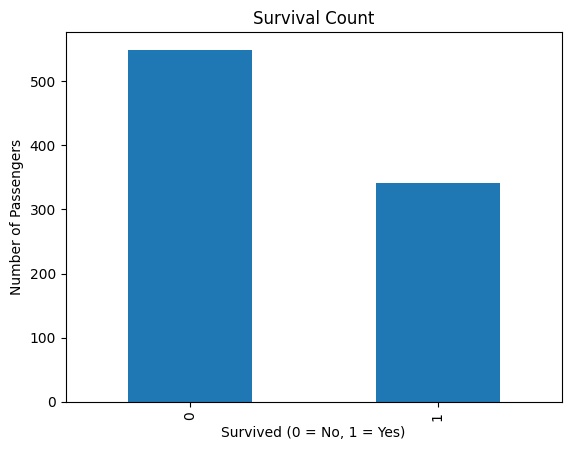

In [30]:
df["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [31]:
df.groupby("Sex")["Survived"].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

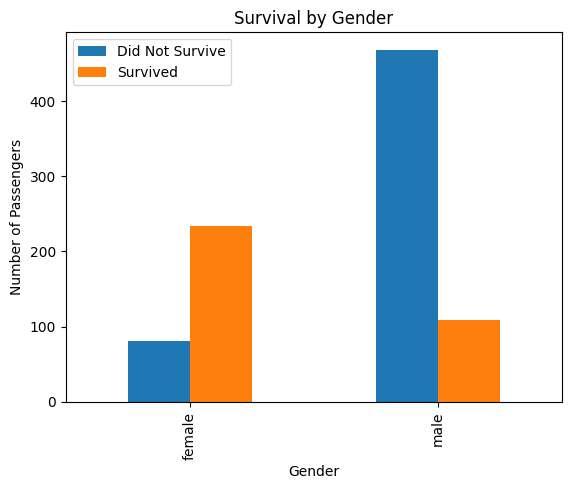

In [32]:
df.groupby("Sex")["Survived"].value_counts().unstack().plot(kind="bar")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])

plt.show()

In [33]:
df.groupby("Pclass")["Survived"].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

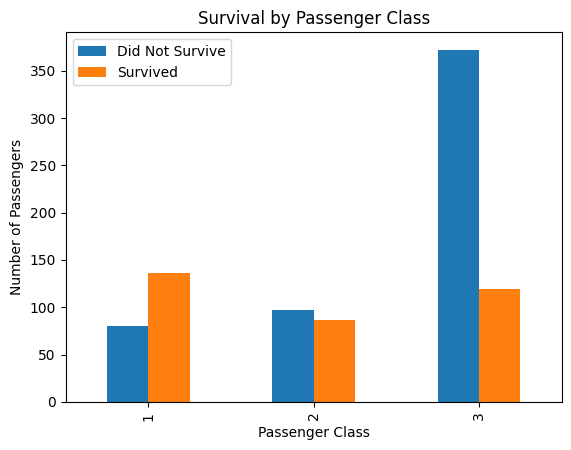

In [34]:
df.groupby("Pclass")["Survived"].value_counts().unstack().plot(kind="bar")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])

plt.show()

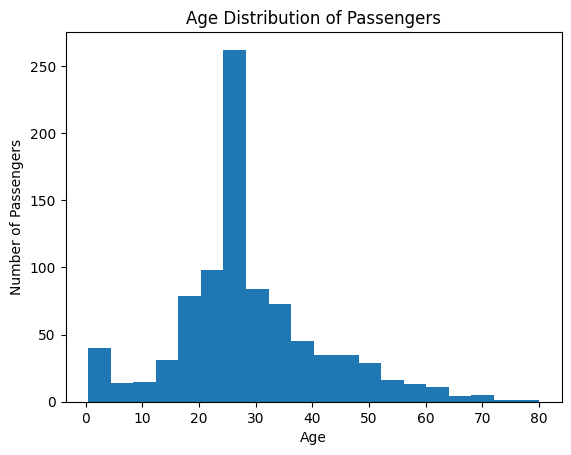

In [35]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

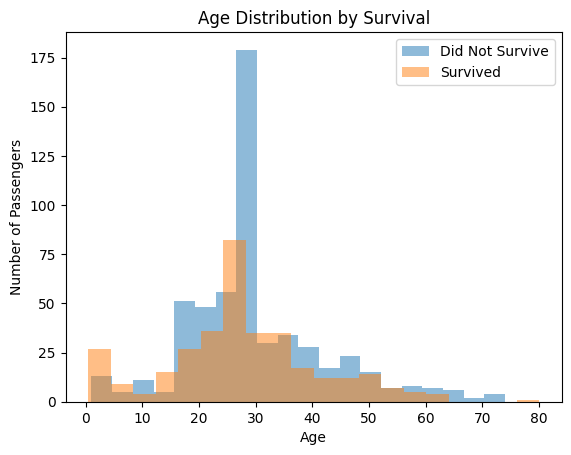

In [36]:
plt.hist(df[df["Survived"] == 0]["Age"], bins=20, alpha=0.5, label="Did Not Survive")
plt.hist(df[df["Survived"] == 1]["Age"], bins=20, alpha=0.5, label="Survived")

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

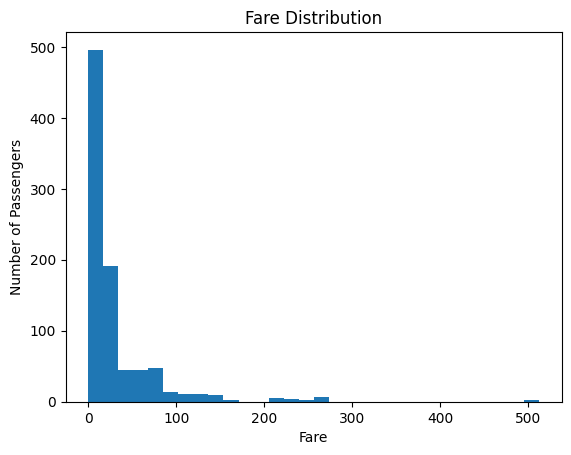

In [37]:
plt.hist(df["Fare"], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [38]:
df.groupby("Survived")["Fare"].mean()

,Fare
Survived,
0,22.117887
1,48.395408


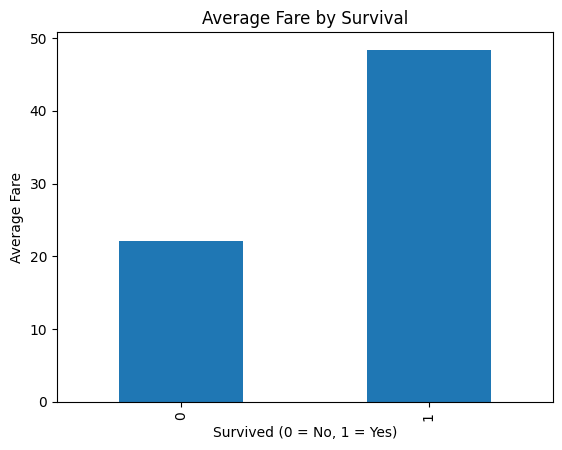

In [39]:
df.groupby("Survived")["Fare"].mean().plot(kind="bar")

plt.title("Average Fare by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Average Fare")

plt.show()

In [40]:
corr = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()

corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


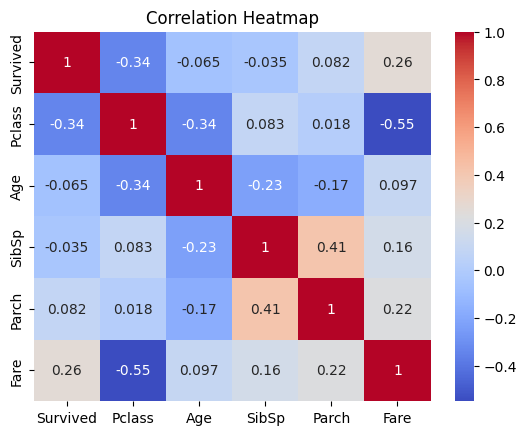

In [41]:
import seaborn as sns

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [42]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [43]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [44]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [46]:
df.to_csv("titanic_cleaned.csv", index=False)

In [47]:
import os
os.listdir("/content")

['.config', 'titanic_cleaned.csv', 'train.csv', 'sample_data']

## Conclusion

The analysis shows that passenger gender, passenger class, and fare were important factors associated with survival. Female passengers and passengers in higher classes had better survival outcomes. Survivors also had a higher average fare than non-survivors.

Missing values in Age and Embarked were successfully handled, and the cleaned dataset was saved as `titanic_cleaned.csv`.